In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [148]:
df = pd.read_csv(r"C:\Users\omkar\AI\AIML Internship\Task5\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [149]:
df.shape

(1025, 14)

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [151]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [152]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<Axes: >

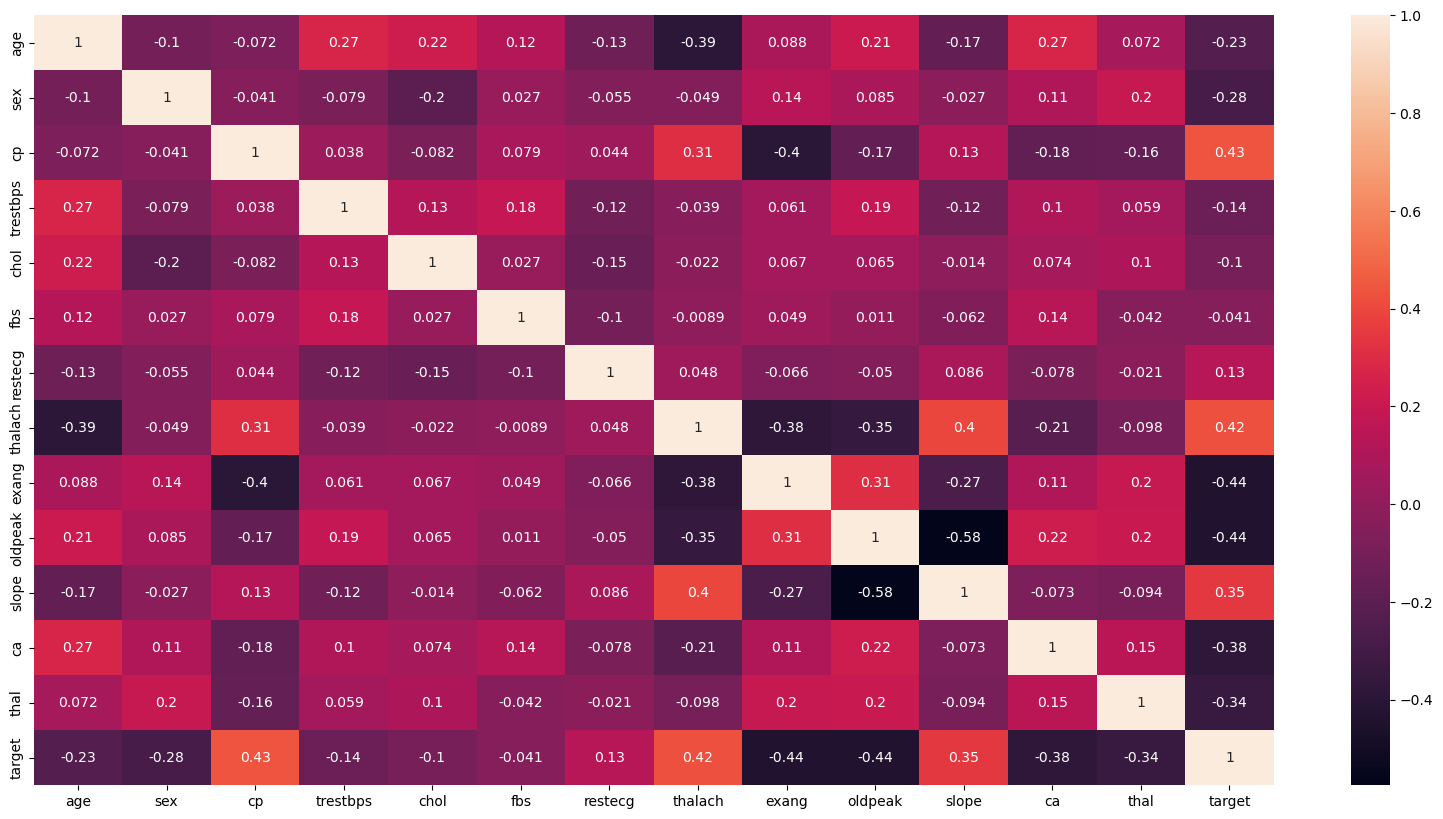

In [153]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)

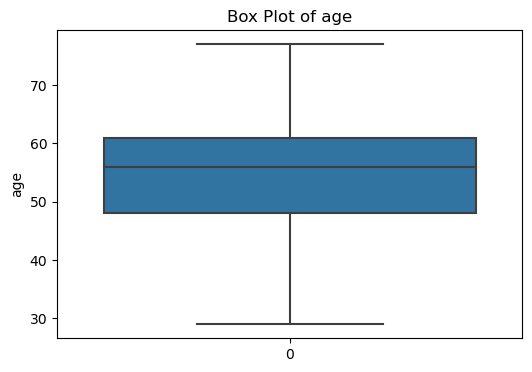

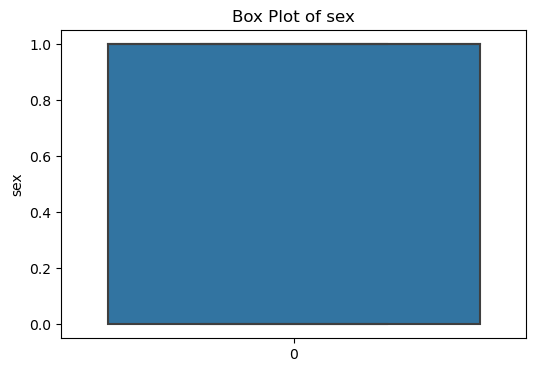

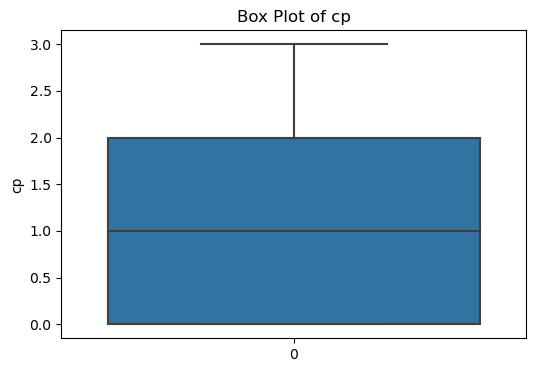

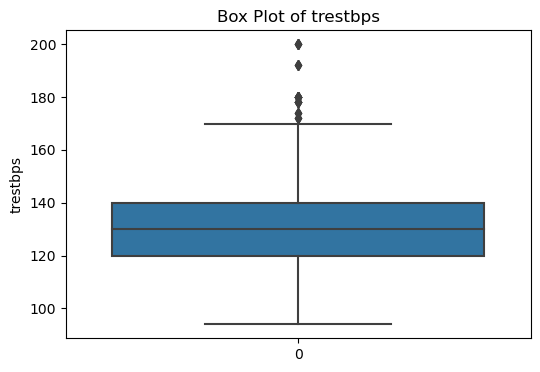

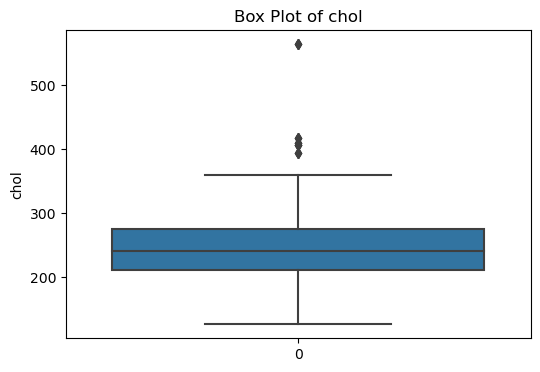

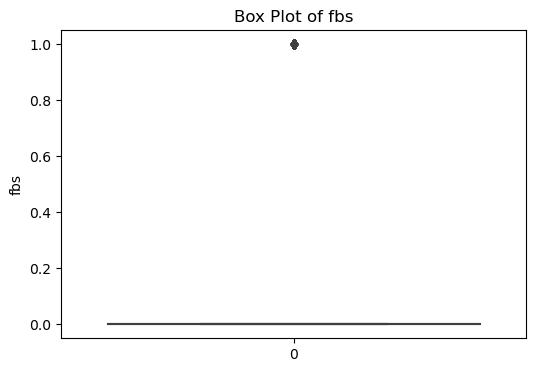

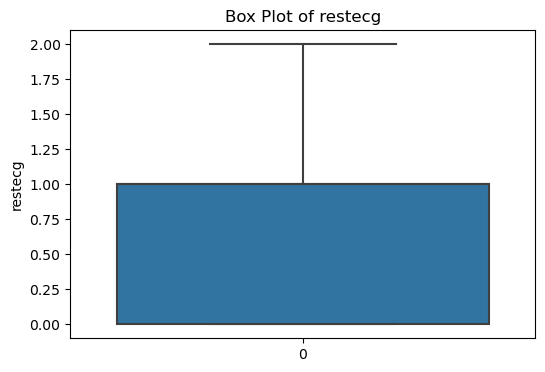

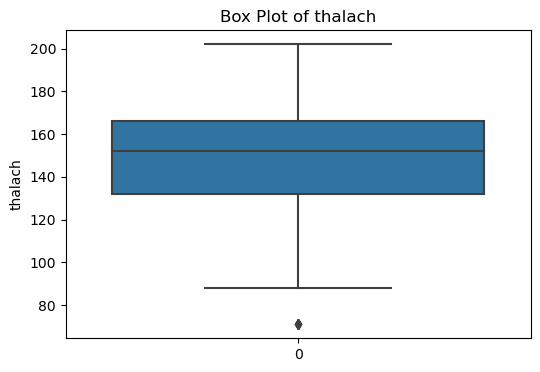

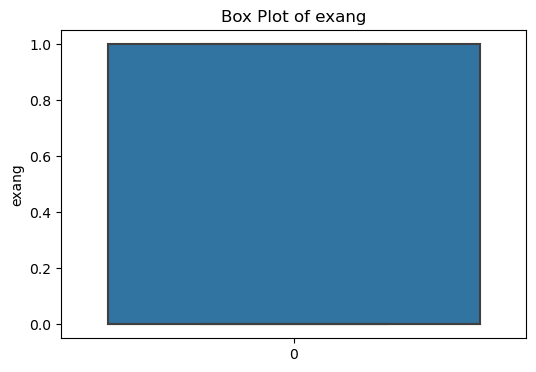

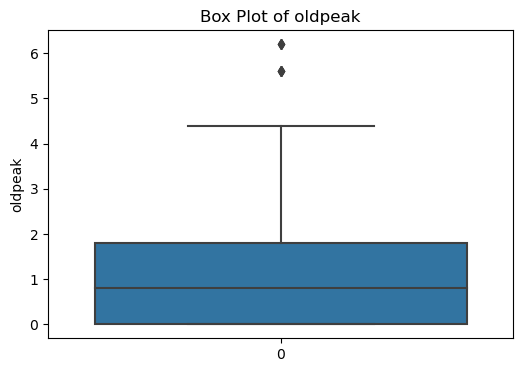

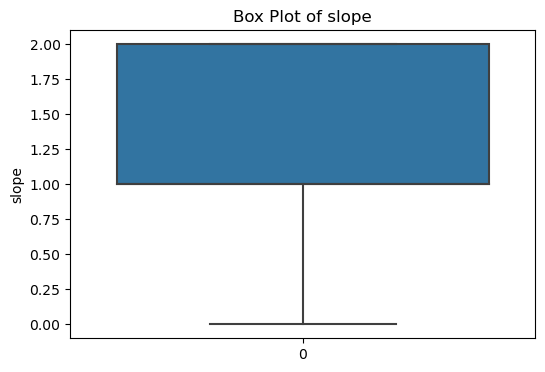

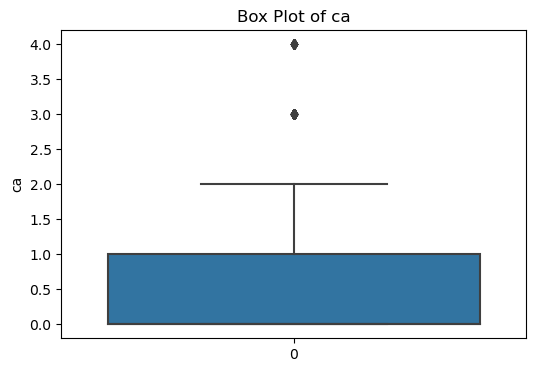

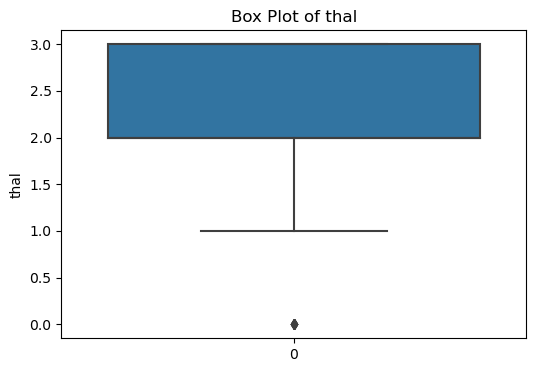

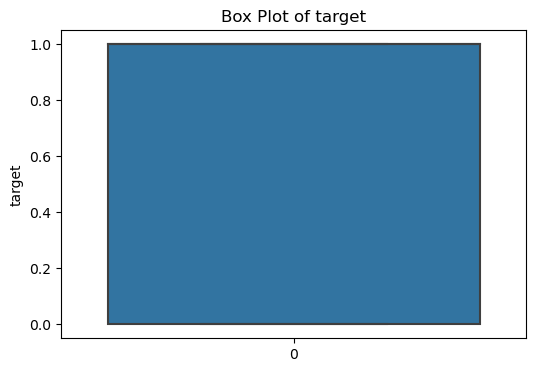

In [154]:
for col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [155]:
for column in df:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

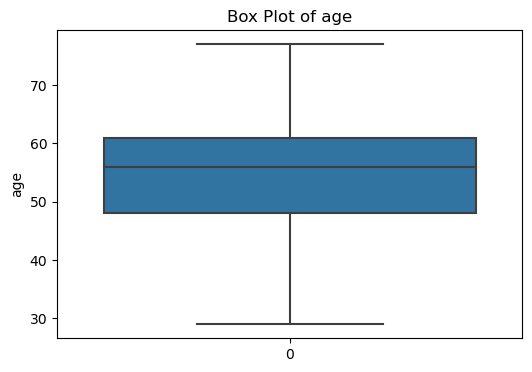

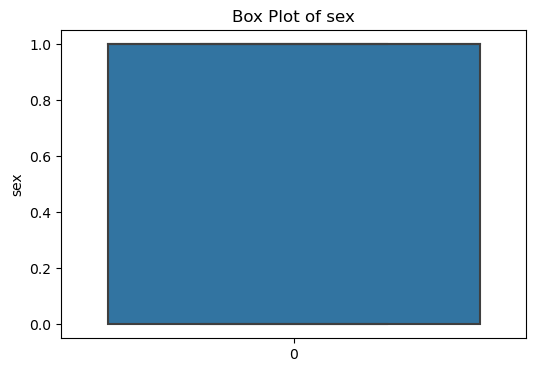

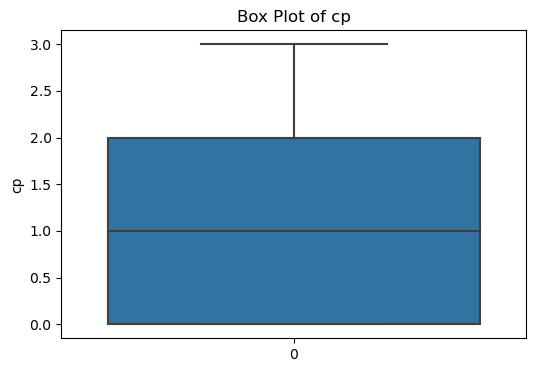

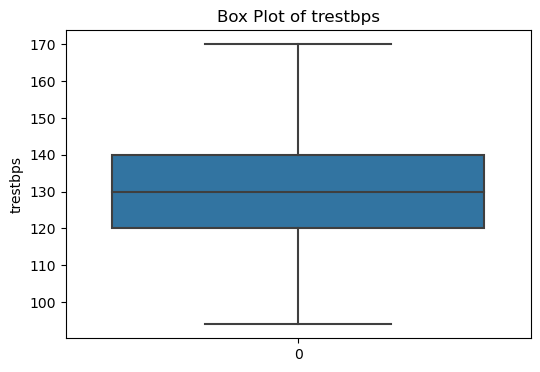

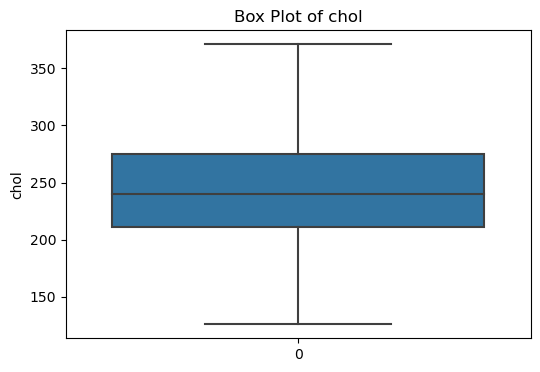

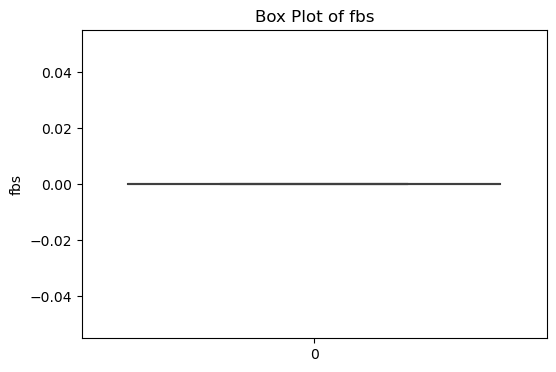

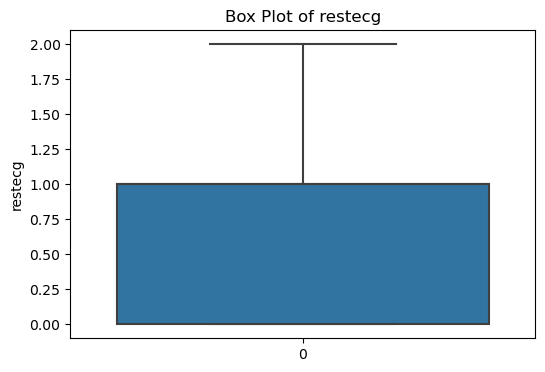

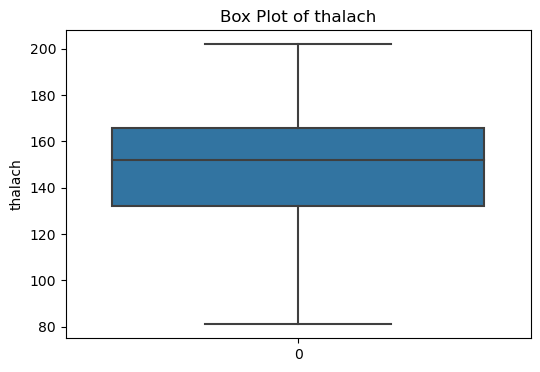

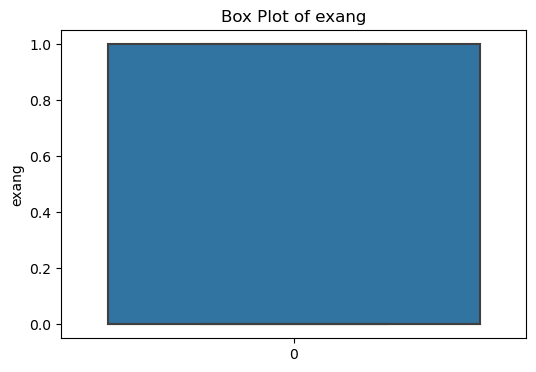

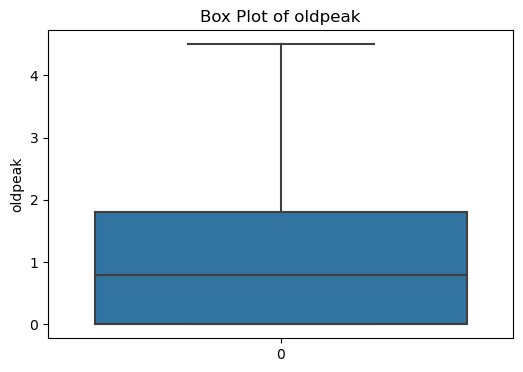

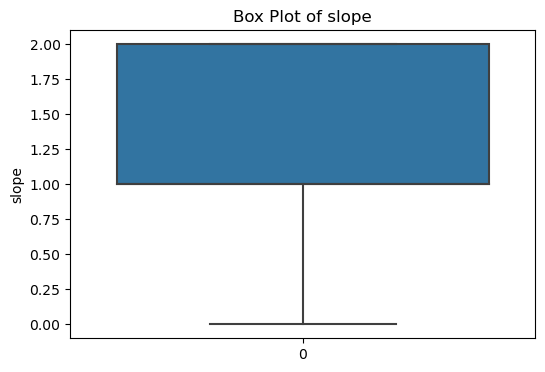

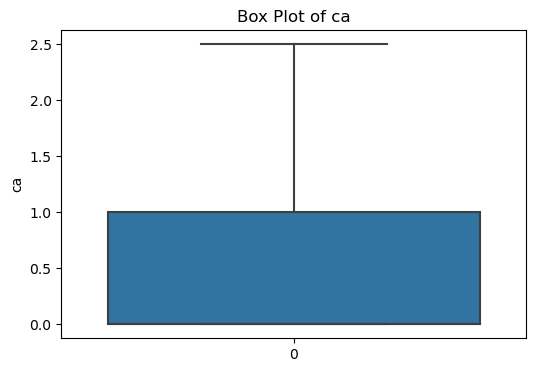

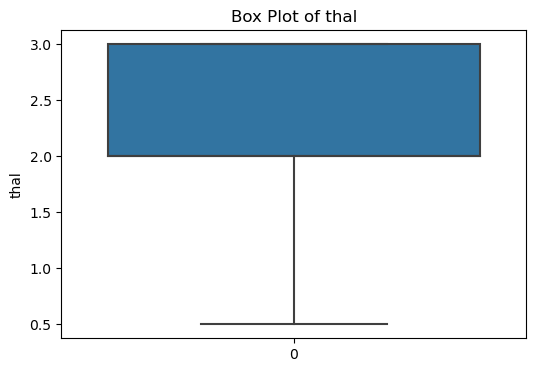

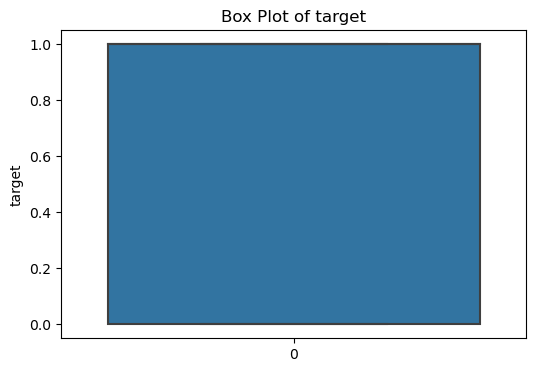

In [156]:
for col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [157]:
df.shape

(1025, 14)

In [158]:
X=df.drop(["fbs", "target"],axis="columns")
y=df['target']

In [159]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [160]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [161]:
dtc = DecisionTreeClassifier(max_depth=4)
dtc.fit(X_train_scaled,y_train)
y_pred = dtc.predict(X_test_scaled)
y_pred_train = dtc.predict(X_train_scaled)
print("Testing Accuracy:- ",accuracy_score(y_test,y_pred))
print("Training Accuracy:- ",accuracy_score(y_train,y_pred_train))

Testing Accuracy:-  0.8344155844155844
Training Accuracy:-  0.8967921896792189


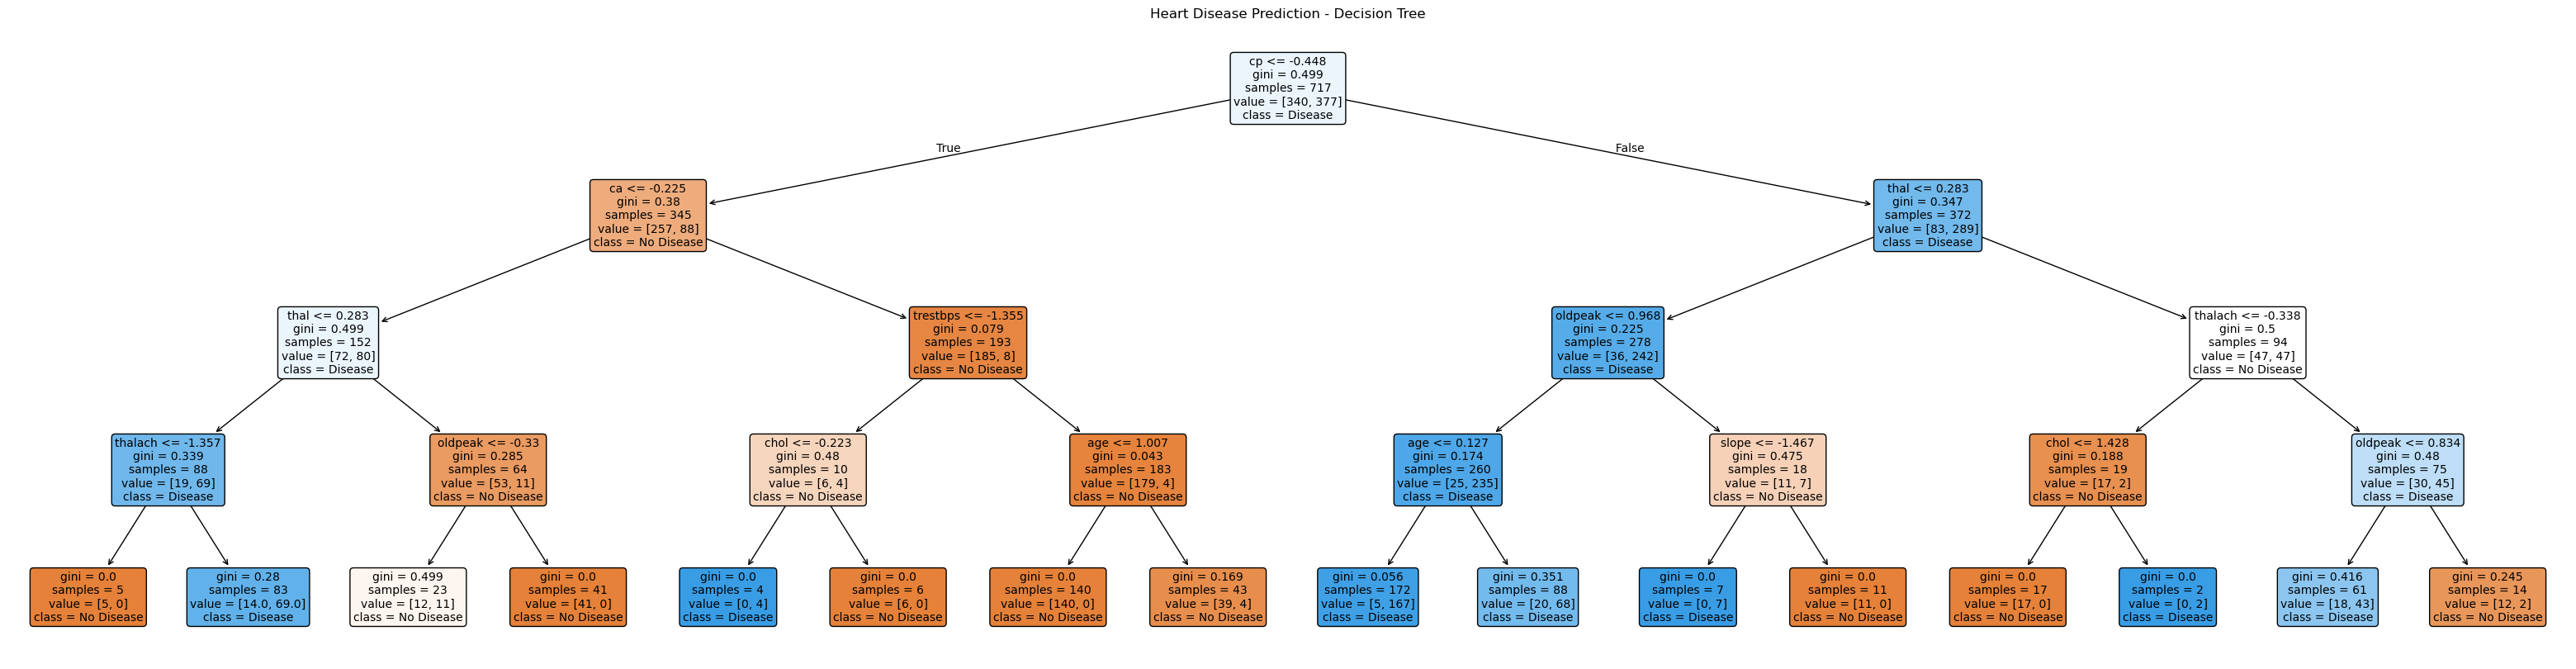

In [162]:
plt.figure(figsize=(40,10))
plot_tree(dtc, 
          feature_names=X.columns, 
          class_names=["No Disease", "Disease"],
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Heart Disease Prediction - Decision Tree")
plt.show()

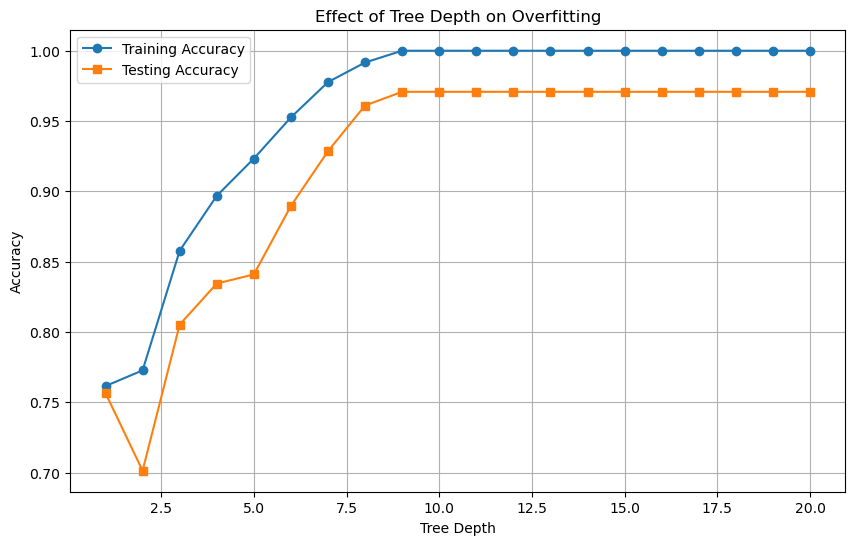

In [163]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []
depths = range(1, 21)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test_scaled)))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, label='Training Accuracy', marker='o')
plt.plot(depths, test_acc, label='Testing Accuracy', marker='s')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Effect of Tree Depth on Overfitting')
plt.legend()
plt.grid(True)
plt.show()


In [164]:
rf = RandomForestClassifier()
rf.fit(X_train_scaled,y_train)
y_pred = rf.predict(X_test_scaled)
y_pred_train = rf.predict(X_train_scaled)
print("Testing Accuracy:- ",accuracy_score(y_test,y_pred))
print("Training Accuracy:- ",accuracy_score(y_train,y_pred_train))

Testing Accuracy:-  0.9805194805194806
Training Accuracy:-  1.0


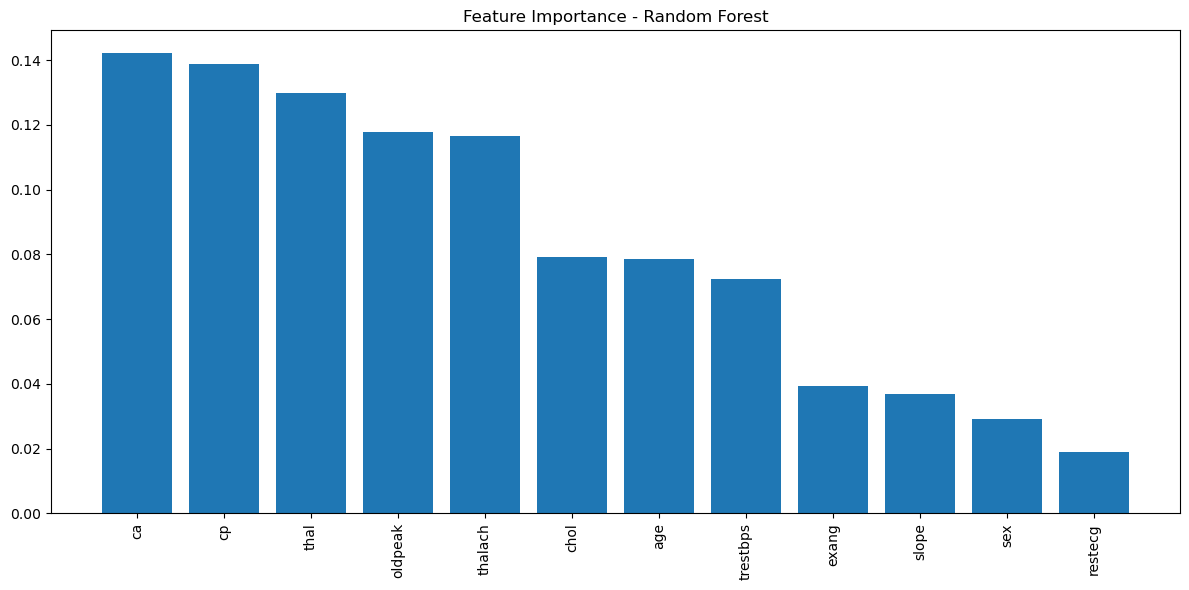

In [165]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [167]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation
dt_cv_scores = cross_val_score(dtc, X, y, cv=5)
rf_cv_scores = cross_val_score(rf, X, y, cv=5)

print("Decision Tree - CV Accuracy:", dt_cv_scores.mean())
print("Random Forest - CV Accuracy:", rf_cv_scores.mean())


Decision Tree - CV Accuracy: 0.8331707317073171
Random Forest - CV Accuracy: 0.9970731707317073


In [ ]:
s